In [1]:
from Simulation.mpc import *
from Simulation.sys_ids import *

## Initialize the system

In [2]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [3]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L
        
system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [4]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [5]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [6]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## MPC implementation

In [7]:
import pickle
import os
data_dir = os.path.join(os.getcwd(), 'Data')
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
save_path = os.path.join(data_dir, "system_dict")
with open(save_path, 'rb') as file:
    system_dict = pickle.load(file)
A = system_dict['A']
B = system_dict['B']
C = system_dict['C']

In [8]:
A_aug, B_aug, C_aug = augment_state_space(A, B, C)

In [9]:
save_path = os.path.join(data_dir, "scaling_factor.pickle")
with open(save_path, 'rb') as file:
    scaling_factor = pickle.load(file)
data_min = scaling_factor["min"]
data_max = scaling_factor["max"]

In [10]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)
L

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\RL_assisted_MPC_polymer\Simulation\mpc.py:124: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182039.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


array([[ 1.52866260e+01,  2.83295401e-02],
       [ 2.06389651e-04,  2.54818174e+02],
       [-6.22268562e+00, -1.39678311e-02],
       [ 1.88488826e-04,  1.48023018e+02],
       [-4.27223666e-01,  1.15300052e-03],
       [ 3.56598267e-01, -6.48780229e-05],
       [ 1.48284425e-01,  3.66178450e-04],
       [ 2.01078812e-01,  4.01799519e-04],
       [ 1.59900173e-06,  7.05926256e+00]])

In [11]:
# y_sp_scenario = np.array([[4.5, 324],
#                           [3.4, 321]])
# y_sp_scenario = np.array([[4.5, 324],
#                           [3.5, 322],
#                           [3.4, 321],
#                           [4.7, 325],
#                           [3.8, 323.5]])
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])
# y_sp_scenario = np.array([[3.42, 321.2],
#                           [3.4, 321]])


y_sp_scenario = apply_min_max(y_sp_scenario, data_min[2:], data_max[2:]) - apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
n_tests = 2
set_points_len = 400

In [12]:
# MPC parameters
n_inputs = 2
predict_h = 9
cont_h = 3
u_ss = apply_min_max(steady_states['ss_inputs'], data_min[:n_inputs], data_max[:n_inputs])
b_min = apply_min_max(np.array([71.6, 78]), data_min[:n_inputs], data_max[:n_inputs])
b_max= apply_min_max(np.array([870, 670]), data_min[:n_inputs], data_max[:n_inputs])
b1 = (b_min[0]-u_ss[0], b_max[0]-u_ss[0])
b2 = (b_min[1]-u_ss[1], b_max[1]-u_ss[1])
bnds = (b1, b2)*cont_h
cons = []
IC_opt = np.zeros(n_inputs*cont_h)
Q1_penalty = 5
Q2_penalty = 1
R1_penalty = 1
R2_penalty = 1
Q1_penalty_r, Q2_penalty_r = 12, 8

In [13]:
MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                    Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                    predict_h, cont_h)

In [14]:
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)

In [15]:
def reward_smooth_integral(delta_y,
                           delta_u,
                           int_error,
                           *,
                           q_err        = 10.0,    # weight on e²
                           lam_abs      = 1.0,   # weight on |e|
                           kappa_bump   = 10.0,    # height of exp bonus
                           sigma_bump   = 0.01,   # width of exp bonus
                           w_I          = 5.0,   # weight on |I|  (positive ⇒ penalty)
                           r_du         = 1.0,   # weight on Δu²
                           clip_val     = 500.0): # numeric guard
    """
    Reward with:
      • quadratic and linear error penalties
      • smooth exponential bonus at zero
      • quadratic Δu penalty
      • leaky‑integral error penalty  (weight w_I)

      r = -q‖e‖²  -λ‖e‖₁  +κ Σ(exp(-|e|/σ)-1)
          -w_I‖I‖₁  -r‖Δu‖²
    """
    e     = np.asarray(delta_y, dtype=float)
    du    = np.asarray(delta_u, dtype=float)
    I     = np.asarray(int_error, dtype=float)

    # 1) instantaneous tracking cost
    quad_err = - q_err   * np.sum(e ** 2)
    lin_err  = - lam_abs * np.sum(np.abs(e))

    # 2) exponential bonus near zero error
    bonus = kappa_bump * np.sum(np.exp(-np.abs(e) / sigma_bump) - 1.0)
    # bonus = kappa_bump * np.sum(np.maximum(0.0, 1.0 - np.abs(e) / sigma_bump))

    # 3) leaky integral penalty (or bonus if you set w_I negative)
    int_pen = - w_I * np.sum(np.abs(I))

    # 4) actuator move penalty
    quad_du = - r_du * np.sum(du ** 2)

    # reward = quad_err + lin_err + bonus + int_pen + quad_du
    reward = quad_err + quad_du + lin_err + bonus
    return float(reward)

In [16]:
def run_mpc(system, MPC_obj, y_sp_scenario, n_tests, set_points_len,
            steady_states, IC_opt, bnds, cons,
            Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L, data_min, data_max, n_inputs, Q1_penalty_r, Q2_penalty_r):
    # defining setpoints
    y_sp, nFE, sub_episodes_changes_dict, time_in_sub_episodes = generate_setpoints(y_sp_scenario, n_tests, set_points_len)

    # Output of the system
    y_mpc = np.zeros((nFE + 1, MPC_obj.C.shape[0]))
    y_mpc[0, :] = system.current_output

    # MPC inputs
    u_mpc = np.zeros((nFE, MPC_obj.B.shape[1]))

    # Record states of the state space model
    x0_model = np.zeros(MPC_obj.A.shape[0])
    xhatdhat = np.zeros((MPC_obj.A.shape[0], nFE + 1))
    yhat = np.zeros((MPC_obj.C.shape[0], nFE))

    # Reward recording
    rewards = np.zeros(nFE)
    avg_rewards = []

    # Record integral of error
    n_y = MPC_obj.C.shape[0]
    I = np.zeros(n_y)
    dt_step = 1.0
    rho = 0.99 # Anti wind-up

    ss_scaled_inputs = apply_min_max(steady_states["ss_inputs"], data_min[:n_inputs], data_max[:n_inputs])
    y_ss_scaled = apply_min_max(steady_states["y_ss"], data_min[n_inputs:], data_max[n_inputs:])

    for i in range(nFE):
        # So we need to apply scaling for MPC because the formulation was in scaled deviation
        scaled_current_input = apply_min_max(system.current_input, data_min[:n_inputs], data_max[:n_inputs])

        # system.Qs = qs[i]
        # system.Qi = qi[i]
        # system.hA = ha[i]

        # Solving MPC optimization problem
        sol = spo.minimize(
            lambda x: MPC_obj.mpc_opt_fun(x, y_sp[i, :], (scaled_current_input - ss_scaled_inputs),
                                          x0_model), IC_opt, bounds=bnds, constraints=cons)

        # take the first control action (this is in scaled deviation form)
        u_mpc[i, :] = sol.x[:MPC_obj.B.shape[1]] + ss_scaled_inputs

        # u (reverse scaling of the mpc)
        u_plant = reverse_min_max(u_mpc[i, :], data_min[:n_inputs], data_max[:n_inputs])

        # Calculate Delta U in scaled deviation form
        delta_u = (u_mpc[i, :] - ss_scaled_inputs) - (scaled_current_input - ss_scaled_inputs)

        # Change the current input
        system.current_input = u_plant

        # Apply the action on the system
        system.step()

        # Record the system output
        y_mpc[i + 1, :] = system.current_output

        # Since the state space calculation is in scaled will transform it
        y_current_scaled = apply_min_max(y_mpc[i+1, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled
        y_current_scaled_model = apply_min_max(y_mpc[i, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled

        # Calculate Delta y in deviation form
        delta_y = y_current_scaled - y_sp[i, :]

        # Signed running sum of the errors (leaky integral)
        I = rho * I + delta_y * dt_step

        # Overall error: norm difference between current scaled output and setpoint
        y_sp_temp = reverse_min_max(y_sp[i, :] + y_ss_scaled, data_min[n_inputs:], data_max[n_inputs:])
        error_norm = np.linalg.norm((y_mpc[i + 1, :] - y_sp_temp).reshape(1, -1), axis=0)
        error_norm = np.abs(error_norm / (y_sp_temp + 1e-15)) * 100.0

        # Calculate the next state in deviation form
        yhat[:, i] = np.dot(MPC_obj.C, xhatdhat[:, i])
        xhatdhat[:, i + 1] = np.dot(MPC_obj.A, xhatdhat[:, i]) + np.dot(MPC_obj.B,
                                                                        (u_mpc[i, :] - ss_scaled_inputs))
        y_pred = MPC_obj.C @ xhatdhat[:, i + 1]
        xhatdhat[:, i+1] += np.dot(L, (y_current_scaled - y_pred)).T
        x0_model = xhatdhat[:, i + 1]

        reward = reward_smooth_integral(delta_y, delta_u, I)

        # Record rewards
        rewards[i] = reward

        # Calculate average reward and printing
        if i in sub_episodes_changes_dict.keys():
            # Averaging the rewards from the last setpoint change till curtrent
            avg_rewards.append(np.mean(rewards[i - time_in_sub_episodes + 1: i]))

            # printing
            print('Sub_Episode : ', sub_episodes_changes_dict[i], ' | avg. reward :', avg_rewards[-1])

    u_mpc = reverse_min_max(u_mpc, data_min[:n_inputs], data_max[:n_inputs])

    return y_mpc, u_mpc, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes, y_sp, yhat

In [17]:
y_mpc, u_mpc, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes, y_sp, yhat = run_mpc(cstr, MPC_obj, y_sp_scenario, n_tests, set_points_len,
            steady_states, IC_opt, bnds, cons,
            Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L, data_min, data_max, n_inputs, Q1_penalty_r, Q2_penalty_r)

Sub_Episode :  1  | avg. reward : -22.94830083198069
Sub_Episode :  2  | avg. reward : -25.857672239035324


In [18]:
def plot_mpc_results(y_sp, steady_states, nFE, delta_t, time_in_sub_episodes, y_mpc, u_mpc, avg_rewards, data_min,
                     data_max, xhatdhat, yhat=None):
    # Canceling the deviation form
    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp = (y_sp + y_ss)
    y_sp = (reverse_min_max(y_sp, data_min[2:], data_max[2:])).T

    ####### Plot 1  ###############
    time_plot = np.linspace(0, nFE * delta_t, nFE + 1)

    time_plot_hour = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes + 1)

    plt.figure(figsize=(10, 8))

    # First subplot
    plt.subplot(2, 1, 1)
    plt.plot(time_plot, y_mpc[:, 0], 'b-', lw=2, label=r'$\mathbf{MPC}$')
    plt.step(time_plot[:-1], y_sp[0, :], 'r--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{\eta}$ (L/g)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    # Second subplot
    plt.subplot(2, 1, 2)
    plt.plot(time_plot, y_mpc[:, 1], 'b-', lw=2, label=r'$\mathbf{MPC}$')
    plt.step(time_plot[:-1], y_sp[1, :], 'r--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{T}$ (K)', fontsize=18)
    plt.xlabel(r'$\mathbf{Time}$ (hour)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    plt.subplot(2, 1, 1)
    plt.tick_params(axis='both', labelsize=16)

    plt.subplot(2, 1, 2)
    plt.tick_params(axis='both', labelsize=16)

    plt.tight_layout()
    plt.show()

    ########### last 400 ##########
    plt.figure(figsize=(10, 8))

    # First subplot
    plt.subplot(2, 1, 1)
    plt.plot(time_plot_hour, y_mpc[nFE - time_in_sub_episodes:, 0], 'b-', lw=2, label=r'$\mathbf{MPC}$')
    plt.step(time_plot_hour[:-1], y_sp[0, nFE - time_in_sub_episodes:], 'r--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{\eta}$ (L/g)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    # Second subplot
    plt.subplot(2, 1, 2)
    plt.plot(time_plot_hour, y_mpc[nFE - time_in_sub_episodes:, 1], 'b-', lw=2, label=r'$\mathbf{MPC}$')
    plt.step(time_plot_hour[:-1], y_sp[1, nFE - time_in_sub_episodes:], 'r--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{T}$ (K)', fontsize=18)
    plt.xlabel(r'$\mathbf{Time}$ (hr)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    plt.subplot(2, 1, 1)
    plt.tick_params(axis='both', labelsize=16)

    plt.subplot(2, 1, 2)
    plt.tick_params(axis='both', labelsize=16)

    plt.tight_layout()
    plt.show()

    ####### Plot 2  ###############
    plt.figure(figsize=(10, 8))

    # First subplot
    plt.subplot(2, 1, 1)
    plt.step(time_plot[:-1], u_mpc[:, 0], 'k-', lw=2, label=r'$\mathbf{Q}_c$')
    plt.ylabel(r'$\mathbf{Q}_c$ (L/h)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    # Second subplot
    plt.subplot(2, 1, 2)
    plt.step(time_plot[:-1], u_mpc[:, 1], 'k-', lw=2, label=r'$\mathbf{Q}_m$')
    plt.ylabel(r'$\mathbf{Q}_m$ (L/h)', fontsize=18)
    plt.xlabel(r'$\mathbf{Time}$ (hour)', fontsize=18)
    plt.grid(True)
    plt.legend(loc='best', fontsize=16)

    plt.subplot(2, 1, 1)
    plt.tick_params(axis='both', labelsize=16)

    plt.subplot(2, 1, 2)
    plt.tick_params(axis='both', labelsize=16)

    plt.tight_layout()
    plt.show()

    ############# Plot 3 (Reward) #######################

    plt.figure(figsize=(10, 6))

    plt.plot(np.arange(1, len(avg_rewards) + 1), avg_rewards, 'ko-', lw=2, label='Reward per Episode')
    plt.ylabel(r'Avg. Reward', fontsize=16, fontweight='bold')
    plt.xlabel(r'Episode #', fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')
    plt.xticks(np.arange(1, len(avg_rewards) + 1), fontsize=14, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=16)

    plt.show()

    if yhat is not None:
        fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

        # For Output 1:
        # Convert real y_mpc[:,0] into scaled deviation: (y - min)/(max-min) - (y_ss in scaled)
        # data_min[2] and data_max[2] assume your first output uses that index
        y_mpc_scaled_1 = ((y_mpc[:, 0] - steady_states["y_ss"][0]) -
                          0.0)  # real domain deviation
        y_mpc_scaled_1 = (y_mpc_scaled_1 - (data_min[2] - data_min[2])) / (data_max[2] - data_min[2])

        axs[0].plot(yhat[0, :], 'b-', linewidth=2, label=r'$\mathbf{T}$ (Observer)')
        axs[0].plot(y_mpc_scaled_1, 'r--', linewidth=2, label=r'$\mathbf{T}$ (Measurement)')
        axs[0].set_ylabel('Scaled Deviation')
        axs[0].set_title('Observer vs. Real (Output 1)')
        axs[0].legend()
        axs[0].grid(True)

        # For Output 2:
        y_mpc_scaled_2 = ((y_mpc[:, 1] - steady_states["y_ss"][1]) -
                          0.0)  # real domain deviation
        y_mpc_scaled_2 = (y_mpc_scaled_2 - (data_min[3] - data_min[3])) / (data_max[3] - data_min[3])

        axs[1].plot(yhat[1, :], 'b-', linewidth=2, label=r'$\mathbf{\eta}$ (Observer)')
        axs[1].plot(y_mpc_scaled_2, 'r--', linewidth=2, label=r'$\mathbf{\eta}$ (Measurement)')
        axs[1].set_xlabel('Time Step')
        axs[1].set_ylabel('Scaled Deviation')
        axs[1].set_title('Observer vs. Real (Output 2)')
        axs[1].legend()
        axs[1].grid(True)

        fig.tight_layout()
        plt.show()

        ###### Plot 3 ########
        fig, axes = plt.subplots(nrows=xhatdhat.shape[0], ncols=1,
                                 figsize=(10, 3 * xhatdhat.shape[0]),
                                 sharex=True)

        for i in range(xhatdhat.shape[0]):
            # Plot RL (xhatdhat)
            axes[i].plot(time_plot, xhatdhat[i, :], 'r-', lw=2, label='RL')
            # Plot MPC (xhatdhat_mpc)
            # axes[i].plot(time_plot, xhatdhat_mpc[i, :], 'y--', lw=2, label='MPC', alpha=0.6)

            # Labeling, grids, etc.
            axes[i].grid(True)
            axes[i].set_ylabel(f'State {i}', fontsize=14)
            axes[i].legend(loc='best', fontsize=12)

        # Label the bottom (shared) X-axis:
        axes[-1].set_xlabel('Time (h)', fontsize=14)

        fig.suptitle('Comparison of RL vs. MPC States', fontsize=16)

        plt.tight_layout(rect=[0, 0, 1, 0.96])

        plt.show()

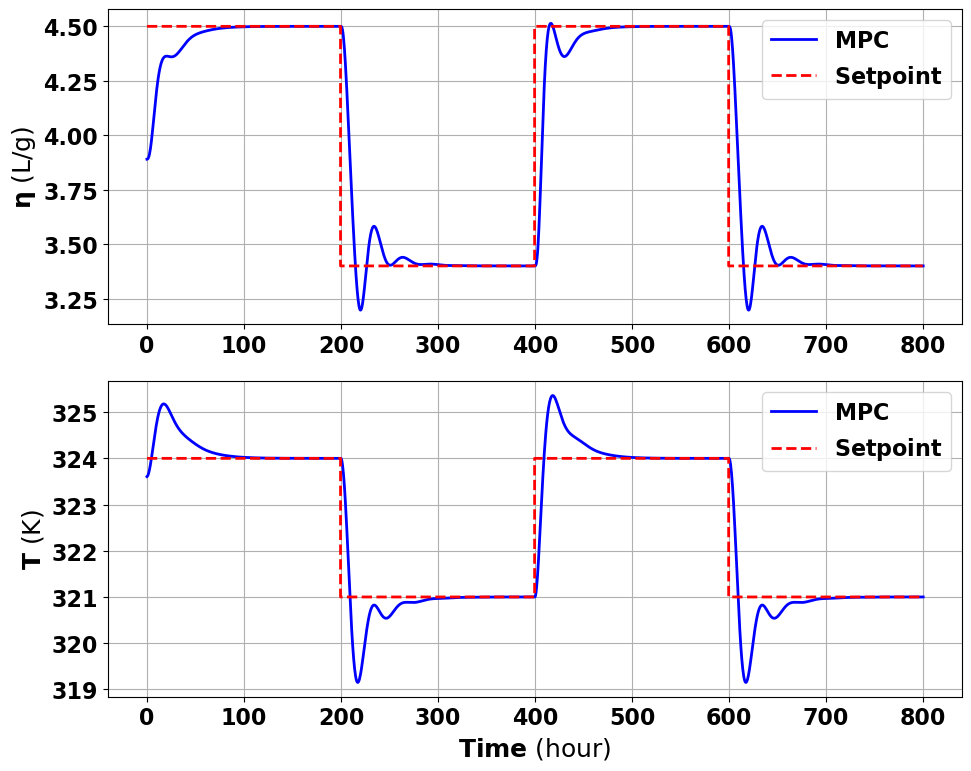

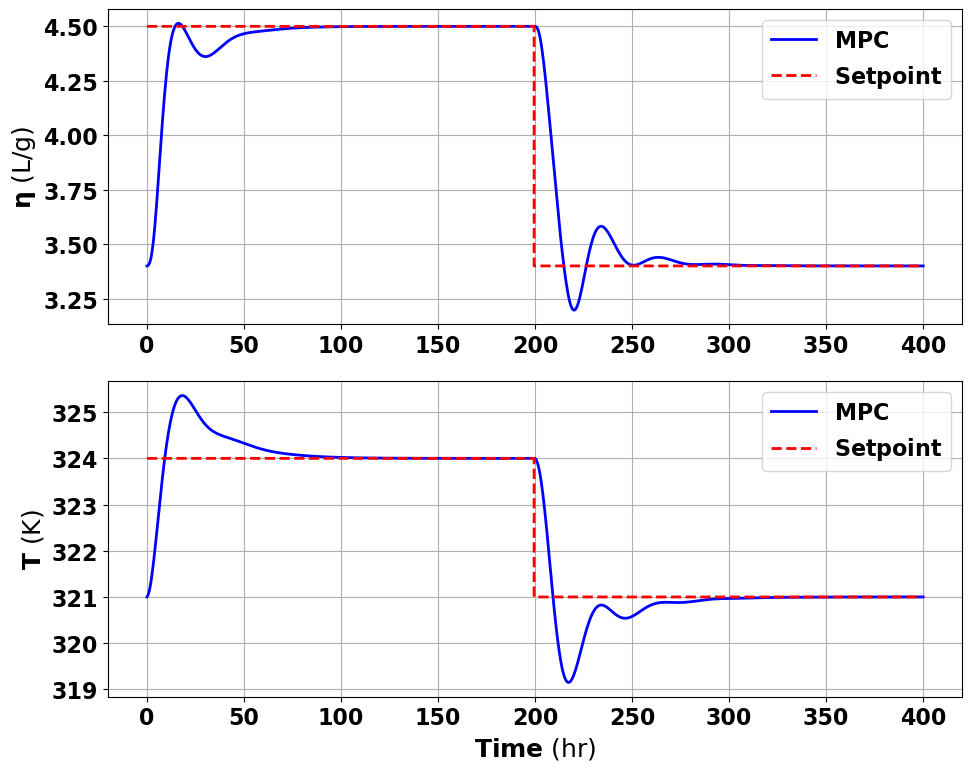

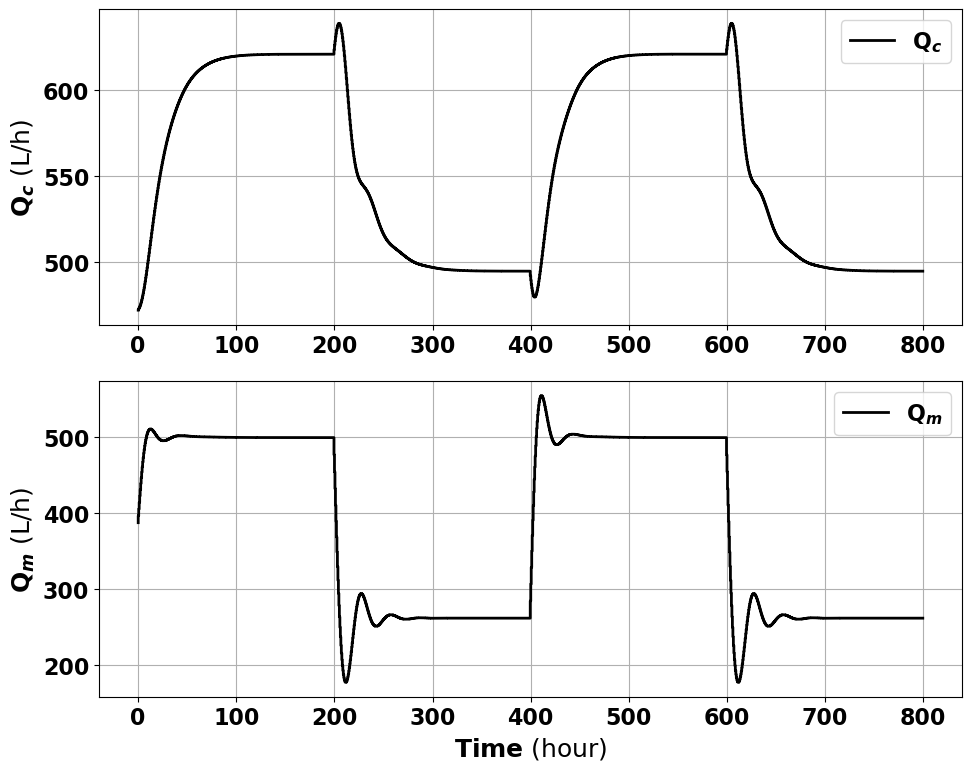

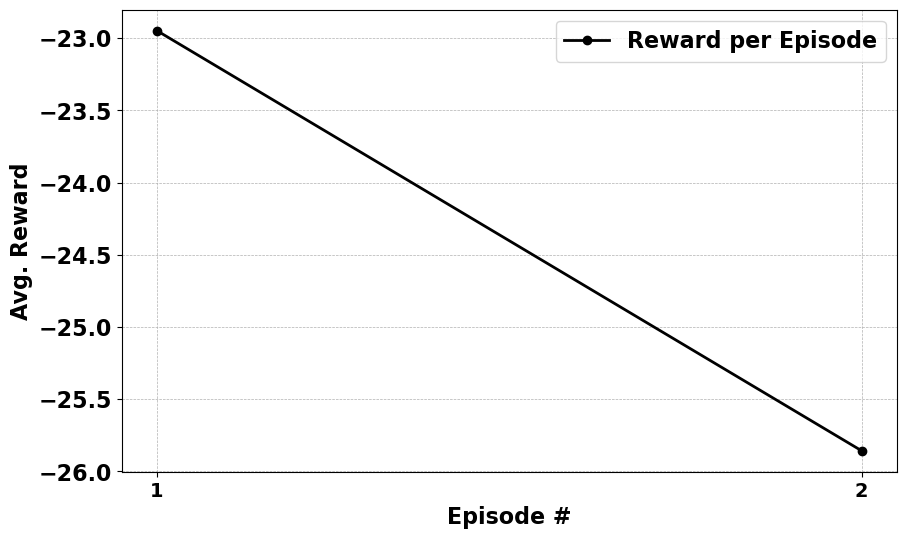

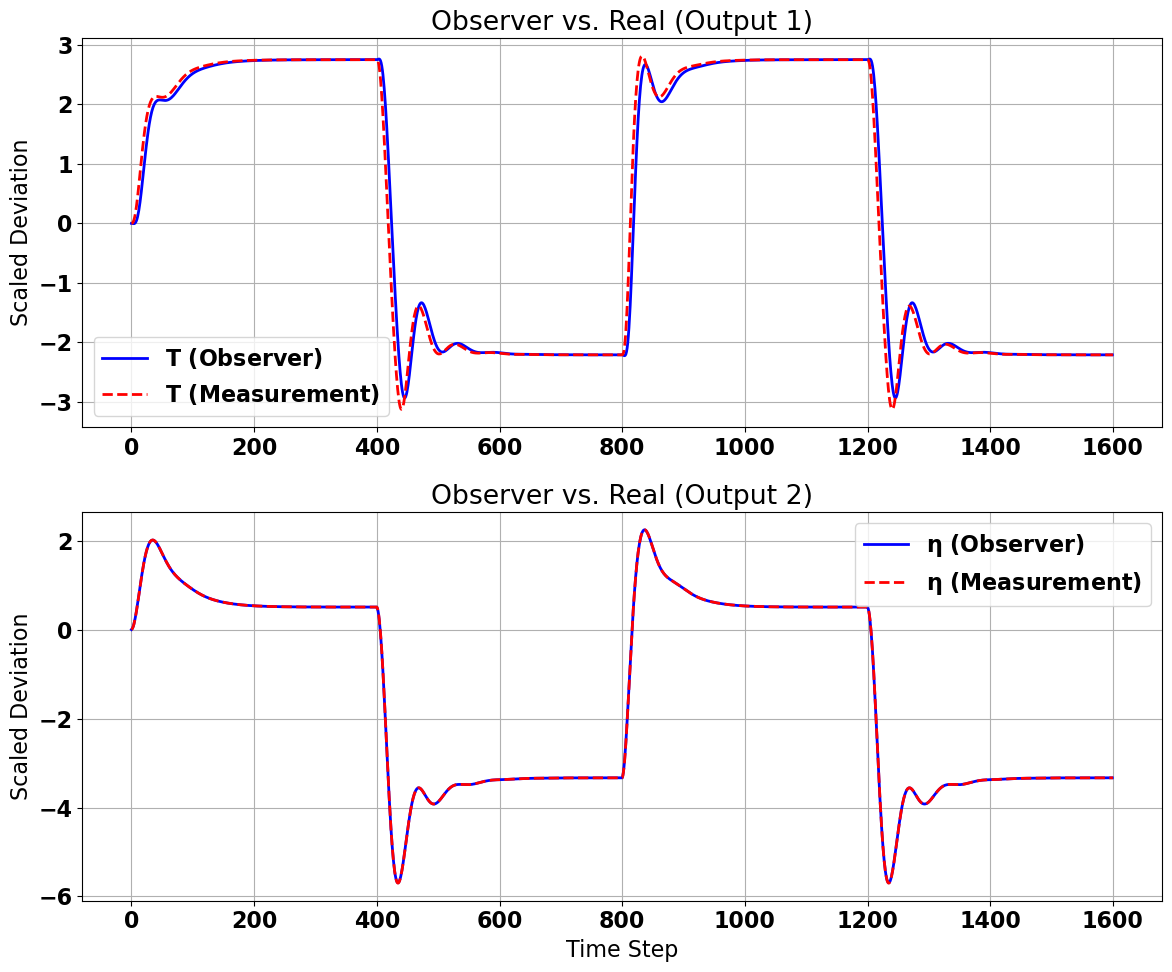

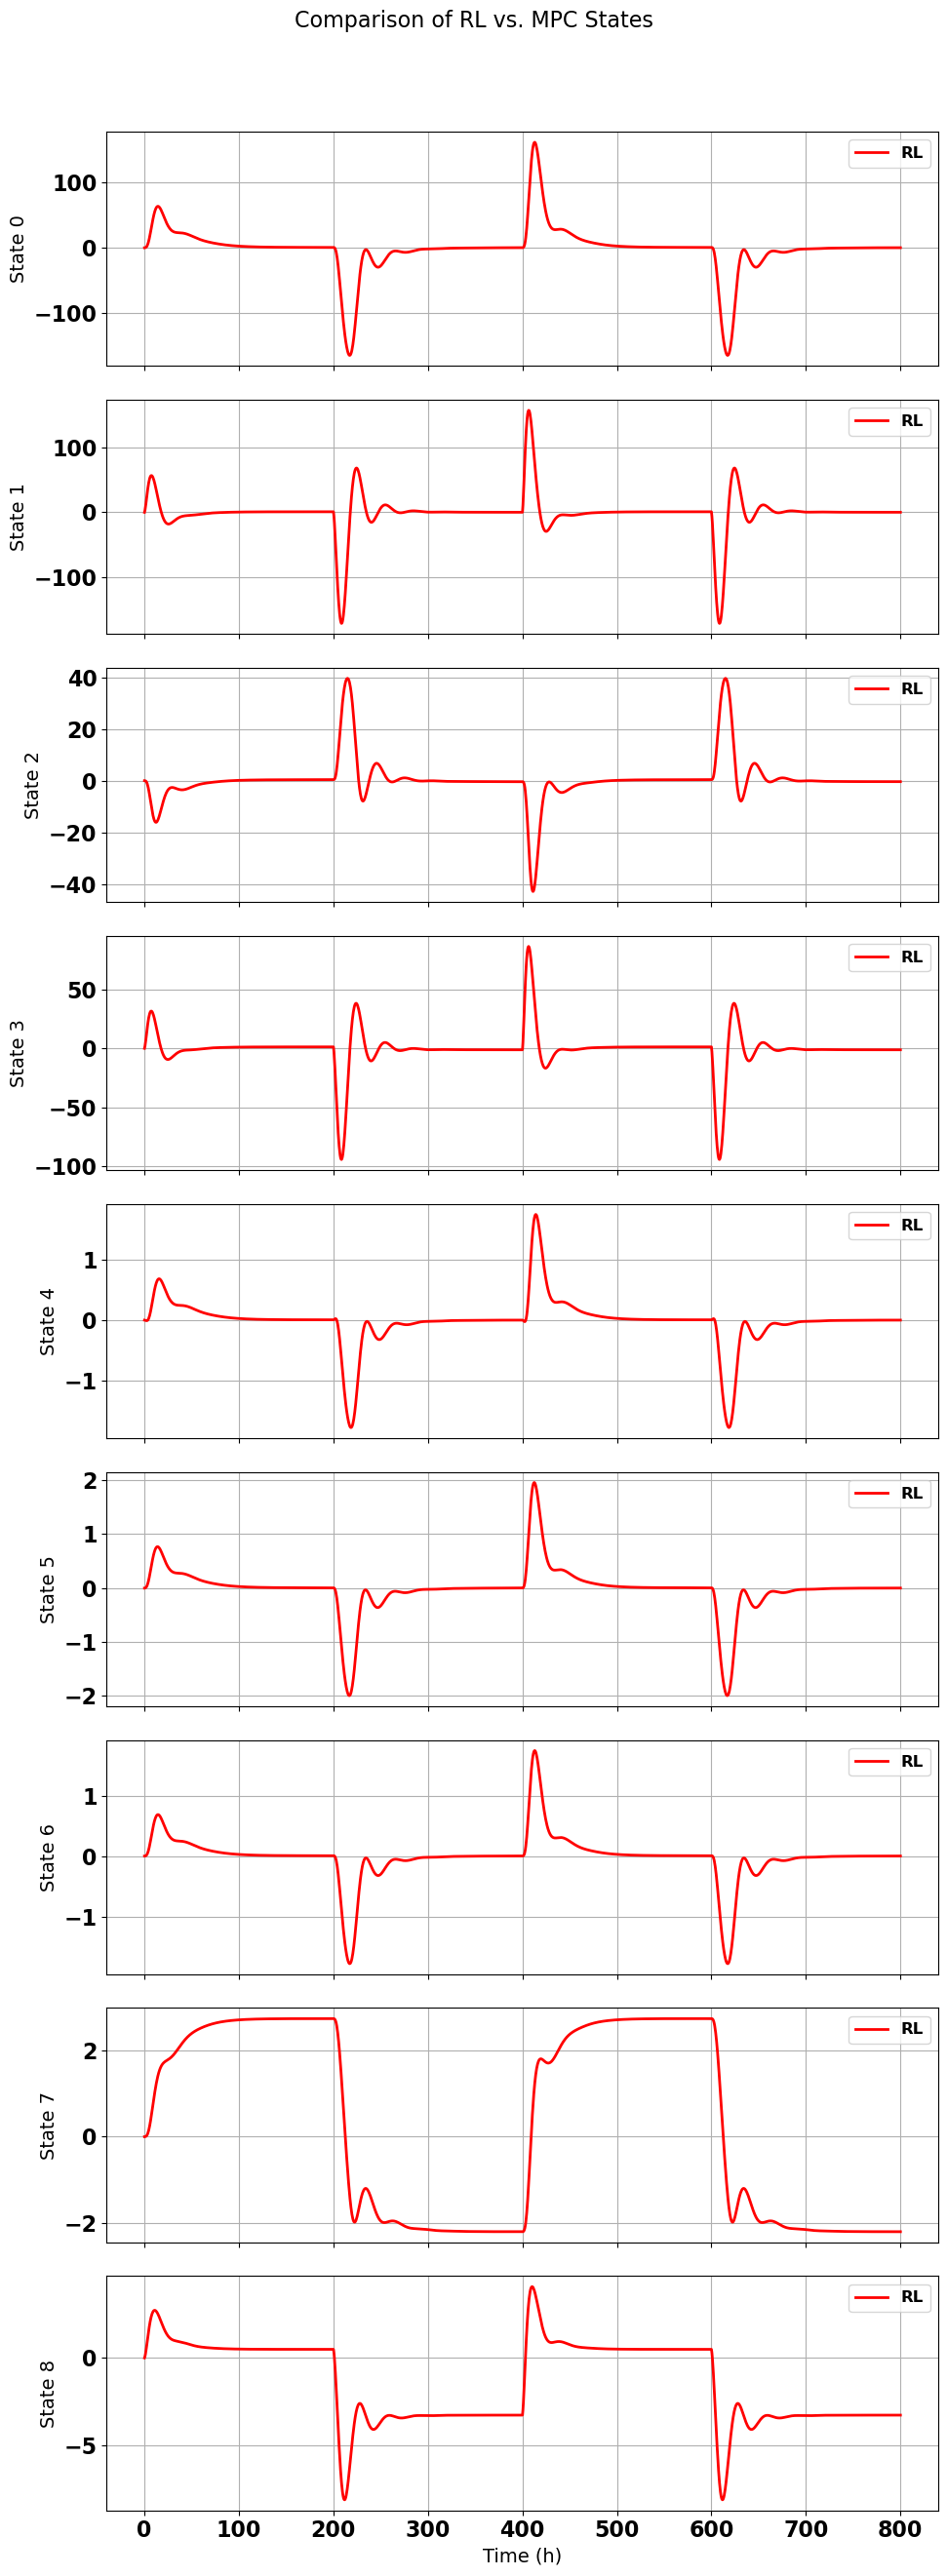

In [19]:
plot_mpc_results(y_sp, steady_states, nFE, delta_t, time_in_sub_episodes, y_mpc, u_mpc, avg_rewards, data_min, data_max, xhatdhat, yhat)

In [20]:
# Storing the inputs and outputs of the MPC
mpc_results = {
    "u_mpc": u_mpc,
    "y_mpc": y_mpc,
    "xhatdhat": xhatdhat
}
save_path = os.path.join(data_dir, "mpc_results.pickle")
with open(save_path, 'wb') as file:
    pickle.dump(mpc_results, file)